# Research Impact Intelligence: A Structured Bibliometric Analysis
# Research Impact Intelligence: Citation Concentration, Collaboration, and Adjusted Scholarly Visibility

## Purpose of the Notebook

This notebook presents a systematic analysis of research impact using publication-level metadata. Rather than treating citation prediction as the sole objective, the analysis examines the distribution, concentration, and correlates of scholarly visibility.

The notebook addresses the following research questions:

1. To what extent are citations concentrated among a relatively small proportion of publications?
2. How does open-access status relate to citation performance after accounting for publication age and field?
3. Is international collaboration associated with stronger citation performance?
4. How does author-team size relate to field- and year-adjusted research impact?
5. Which countries and journals demonstrate comparatively strong visibility within the dataset?
6. Can publications be grouped into meaningful descriptive archetypes?
7. Which records exhibit unusual bibliometric characteristics and therefore warrant closer examination?
8. Which keywords frequently occur together across publications?
9. Can a transparent classification benchmark identify publications with comparatively high adjusted impact?

---

<br>

<div align="center">

## If you find this notebook useful, please consider giving it an **Upvote**!

Your support helps increase the visibility of this work and encourages the development of more open, reproducible bibliometric analyses.

 **Comments, suggestions, and feedback are always welcome.**

</div>

<br>

---

## Analytical Framework

The notebook follows a sequential workflow:

| Stage | Analytical Task |
|---|---|
| 1 | Import libraries and establish reproducible settings |
| 2 | Load the dataset across Kaggle, Google Colab, or local environments |
| 3 | Conduct a data-quality and usability audit |
| 4 | Clean the data and construct analysis-ready variables |
| 5 | Profile the scope and coverage of the dataset |
| 6 | Measure citation concentration and inequality |
| 7 | Examine open-access performance |
| 8 | Assess international collaboration |
| 9 | Compare author-team structures |
| 10 | Evaluate country- and journal-level visibility |
| 11 | Identify publication archetypes through clustering |
| 12 | Detect unusual observations |
| 13 | Analyse keyword frequency and co-occurrence |
| 14 | Develop a high-impact classification benchmark |
| 15 | Export reusable analytical outputs |
| 16 | Summarise interpretation principles and limitations |

> **Methodological Position**  
> The notebook is designed primarily for exploratory and descriptive analysis. Observed relationships should not be interpreted as causal effects unless supported by an appropriate research design.

## 1. Computational Environment and Reproducibility

This section imports the libraries required for data manipulation, visualisation, clustering, anomaly detection, and predictive modelling. Display settings and random seeds are established to support reproducibility and consistent presentation.

> **Reproducibility Note**  
> Results generated by stochastic algorithms may vary unless a fixed random state is used. The notebook therefore applies a common random seed wherever the selected method permits.


In [ ]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
RANDOM_STATE = 42

## 2. Dataset Acquisition and Environment-Agnostic Loading

The following procedure loads the citation metadata file in Kaggle, Google Colab, or a local Python environment. The loading logic searches standard directories and avoids dependence on a single platform-specific path.

### Expected Input

The dataset should contain publication-level records, including bibliographic, authorship, institutional, access-status, and citation variables.

> **Data Governance Note**  
> Before distributing or publishing derived outputs, users should confirm that the source dataset permits reuse and that no restricted or personally identifiable information is present.


In [ ]:
# # GOOGLE COLAB: Upload and load the CSV file

# import pandas as pd
# from google.colab import files
# from io import BytesIO

# uploaded = files.upload()

# # Automatically select the uploaded CSV file
# csv_files = [
#     filename for filename in uploaded.keys()
#     if filename.lower().endswith(".csv")
# ]

# if not csv_files:
#     raise FileNotFoundError("No CSV file was uploaded.")

# DATA_PATH = csv_files[0]

# df_raw = pd.read_csv(BytesIO(uploaded[DATA_PATH]))

# print(f"Loaded file: {DATA_PATH}")
# print(f"Dataset shape: {df_raw.shape}")

# display(df_raw.head())

Saving Cited Paper Meta Data (csv).csv to Cited Paper Meta Data (csv).csv
Loaded file: Cited Paper Meta Data (csv).csv
Dataset shape: (9966, 33)


,paper_id,doi,paper_title,abstract,publication_year,publication_date,paper_type,language,journal,publisher,source_type,open_access,open_access_status,field_of_study,keywords,number_of_authors,authors,first_author,institution,number_of_institutions,institution_country,international_collaboration,references_count,citation_count,title_length_words,abstract_length_words,keyword_count,publication_age,citation_count_log,references_count_log,number_of_authors_log,title_abstract_text,citation_rate_per_year
0,https://openalex.org/W1901616594,https://doi.org/10.1126/science.aaa8415,"Machine learning: Trends, perspectives, and prospects",Machine learning addresses the question of how to build computers that improve automat...,2015,7/16/2015,review,en,Science,American Association for the Advancement of Science,journal,0,closed,Intersection (aeronautics),Intersection (aeronautics); Computer science; Artificial intelligence; Core (optical f...,2,Michael I. Jordan; Tom M. Mitchell,Michael I. Jordan,Carnegie Mellon University,2,US,0,32,9577,6,110,10,12,9.167224,3.496508,1.098612,"Machine learning: Trends, perspectives, and prospects Machine learning addresses the q...",798.083333
1,https://openalex.org/W2953384591,https://doi.org/10.48550/arxiv.1605.08695,TensorFlow: A system for large-scale machine learning,TensorFlow is a machine learning system that operates at large scale and in heterogene...,2016,5/27/2016,preprint,en,arXiv (Cornell University),Cornell University,repository,1,green,Scale (ratio),Scale (ratio); Computer science; Artificial intelligence; Machine learning; Cartograph...,22,Martı́n Abadi; Paul Barham; Jianmin Chen; Zhifeng Chen; Andy Davis; Jay B. Dean; Matth...,Martı́n Abadi,Google (United States),1,US,0,56,8825,7,172,6,11,9.085457,4.043051,3.135494,TensorFlow: A system for large-scale machine learning TensorFlow is a machine learning...,802.272727
2,https://openalex.org/W2271840356,https://doi.org/10.48550/arxiv.1603.04467,TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems,"TensorFlow is an interface for expressing machine learning algorithms, and an implemen...",2016,3/14/2016,preprint,en,arXiv (Cornell University),Cornell University,repository,1,green,Scale (ratio),Scale (ratio); Computer science; Artificial intelligence; Machine learning; Distribute...,40,Martı́n Abadi; Ashish Agarwal; Paul Barham; Eugene Brevdo; Zhifeng Chen; Craig Citro; ...,Martı́n Abadi,Unknown,0,Unknown,0,42,9777,8,178,7,11,9.187890,3.761200,3.713572,TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems TensorFl...,888.818182
3,https://openalex.org/W2912213068,https://doi.org/10.1145/3298981,Federated Machine Learning,"Today’s artificial intelligence still faces two major challenges. One is that, in most...",2019,1/28/2019,article,en,ACM Transactions on Intelligent Systems and Technology,Association for Computing Machinery,journal,0,closed,Computer science,Computer science; Federated learning; Transfer of learning; Artificial intelligence; D...,4,Qiang Yang; Yang Liu; Tianjian Chen; Yongxin Tong,Qiang Yang,Beihang University,2,CN,1,85,5873,3,120,6,8,8.678291,4.454347,1.609438,Federated Machine Learning Today’s artificial intelligence still faces two major chall...,734.125000
4,https://openalex.org/W2402144811,https://doi.org/10.5555/3026877.3026899,TensorFlow: a system for large-scale machine learning,TensorFlow is a machine learning system that operates at large scale and in heterogene...,2016,11/2/2016,article,en,Operating Systems Design and Implementation,Unknown,conference,0,closed,Dataflow,Dataflow; Computer science; Artificial intelligence; Multi-core processor; Machine lea...,22,Martı́n Abadi; Paul Barham; Jianmin Chen; Zhifeng Chen; Andy Davis; Jay B. Dean; Matth...,Martı́n Abadi,Google (United States),1,US,0,55,6355,7,165,10,11,8.757155,4.025352,3.135494,TensorFlow: a system for large-scale machine learning TensorFlow is a machine learning...,577.727273


In [ ]:
# KAGGLE: Locate and load the CSV from /kaggle/input

import pandas as pd
from pathlib import Path

csv_files = list(Path("/kaggle/input").rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found. Use 'Add Input' to attach the dataset."
    )

print("CSV files found:")

for index, file_path in enumerate(csv_files):
    print(f"{index}: {file_path}")

# Try to identify the citation metadata file
matching_files = [
    file_path for file_path in csv_files
    if any(
        word in file_path.name.lower()
        for word in ["cited", "citation", "paper", "meta"]
    )
]

if matching_files:
    DATA_PATH = matching_files[0]
elif len(csv_files) == 1:
    DATA_PATH = csv_files[0]
else:
    raise FileNotFoundError(
        "Multiple CSV files were found. Set DATA_PATH manually "
        "using one of the paths displayed above."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"\nLoaded file: {DATA_PATH}")
print(f"Dataset shape: {df_raw.shape}")

display(df_raw.head())

## 3. Data-Quality and Usability Audit

Before undertaking substantive analysis, the dataset is examined for structural and content-related issues. The audit considers:

- variable type;
- missing-value frequency;
- number of distinct values;
- constant variables;
- duplicated publication identifiers;
- fully duplicated records; and
- implausible numerical values.

This stage is necessary because bibliometric findings may be materially affected by duplicate records, incomplete metadata, inconsistent coding, or invalid publication dates.

> **Quality-Control Principle**  
> A technically successful model does not compensate for poor input data. Data validity should therefore be assessed before any inferential or predictive procedure is applied.


In [ ]:
def data_audit(data):
    audit = pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "missing_n": data.isna().sum(),
        "missing_pct": (data.isna().mean() * 100).round(2),
        "unique_n": data.nunique(dropna=True),
    })
    audit["is_constant"] = audit["unique_n"] <= 1
    return audit.sort_values(["missing_pct", "unique_n"], ascending=[False, True])

audit_table = data_audit(df_raw)
print("Duplicate paper_id rows:", df_raw.duplicated("paper_id").sum())
print("Fully duplicated rows:", df_raw.duplicated().sum())
display(audit_table.head(15))

Duplicate paper_id rows: 0
Fully duplicated rows: 0


,dtype,missing_n,missing_pct,unique_n,is_constant
doi,object,125,1.25,9841,False
first_author,object,9,0.09,8885,False
authors,object,9,0.09,9725,False
language,object,4,0.04,5,False
open_access,int64,0,0.00,2,False
international_collaboration,int64,0,0.00,2,False
source_type,object,0,0.00,6,False
open_access_status,object,0,0.00,6,False
keyword_count,int64,0,0.00,10,False
publication_year,int64,0,0.00,11,False


In [ ]:
# Simple validity checks for important numerical columns
numeric_checks = pd.DataFrame({
    "metric": ["negative citations", "negative references", "zero publication age", "future publication year"],
    "count": [
        (df_raw["citation_count"] < 0).sum(),
        (df_raw["references_count"] < 0).sum(),
        (df_raw["publication_age"] <= 0).sum(),
        (df_raw["publication_year"] > pd.Timestamp.today().year).sum(),
    ]
})
numeric_checks

,metric,count
0,negative citations,0
1,negative references,0
2,zero publication age,0
3,future publication year,0


## 4. Data Preparation and Construction of Analytical Variables

A working copy of the original dataset is created to preserve the source records. The preparation procedure standardises text fields, converts numerical variables, removes duplicated publication identifiers, and constructs interpretable measures of research impact.

The principal derived variables include:

| Variable | Definition |
|---|---|
| Annual citation rate | Citation count divided by publication age |
| Log annual citation rate | Natural logarithm of one plus the annual citation rate |
| Citations per reference | Citation count divided by reference count |
| Team-size group | Categorised number of authors |
| Keyword list | Normalised list derived from semicolon-separated keywords |

> **Analytical Caution**  
> Citation rates are sensitive to publication age, disciplinary citation practices, database coverage, and indexing delays. They should therefore be interpreted as comparative indicators rather than complete measures of scholarly quality.


In [ ]:
df = df_raw.copy()
df = df.drop_duplicates(subset="paper_id").reset_index(drop=True)

df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")

text_cols = [
    "paper_title", "abstract", "paper_type", "language", "journal", "publisher",
    "source_type", "open_access_status", "field_of_study", "keywords", "authors",
    "first_author", "institution", "institution_country"
]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

numeric_cols = [
    "publication_year", "number_of_authors", "number_of_institutions",
    "references_count", "citation_count", "title_length_words",
    "abstract_length_words", "keyword_count", "publication_age"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["publication_age_safe"] = df["publication_age"].clip(lower=1)
df["annual_citation_rate"] = df["citation_count"] / df["publication_age_safe"]
df["log_annual_citation_rate"] = np.log1p(df["annual_citation_rate"])
df["citations_per_reference"] = df["citation_count"] / df["references_count"].replace(0, np.nan)

df["team_size_group"] = pd.cut(
    df["number_of_authors"],
    bins=[0, 1, 3, 6, 10, np.inf],
    labels=["Solo", "2-3", "4-6", "7-10", "11+"],
    include_lowest=True
)

def split_terms(value):
    if pd.isna(value) or str(value).strip().lower() in {"", "unknown", "nan"}:
        return []
    return sorted({term.strip().lower() for term in str(value).split(";") if term.strip()})

df["keyword_list"] = df["keywords"].apply(split_terms)
print(f"Analysis-ready rows: {len(df):,}")
df[["paper_title", "citation_count", "annual_citation_rate", "team_size_group"]].head()

Analysis-ready rows: 9,966


,paper_title,citation_count,annual_citation_rate,team_size_group
0,"Machine learning: Trends, perspectives, and prospects",9577,798.083333,2-3
1,TensorFlow: A system for large-scale machine learning,8825,802.272727,11+
2,TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems,9777,888.818182,11+
3,Federated Machine Learning,5873,734.125000,4-6
4,TensorFlow: a system for large-scale machine learning,6355,577.727273,11+


## 5. Dataset Scope, Coverage, and Temporal Distribution

This section summarises the breadth of the dataset by reporting the number of publications, journals, publishers, countries, fields of study, and publication years represented.

The temporal distribution is also examined to determine whether the dataset is concentrated in particular years. Such concentration may influence subsequent comparisons because recent publications have had less time to accumulate citations.

> **Interpretation Note**  
> Dataset coverage should not be assumed to represent the complete scholarly literature unless the sampling and collection procedures establish such representativeness.


In [ ]:
profile = pd.Series({
    "papers": len(df),
    "publication_year_min": int(df["publication_year"].min()),
    "publication_year_max": int(df["publication_year"].max()),
    "journals": df["journal"].nunique(),
    "publishers": df["publisher"].nunique(),
    "countries": df["institution_country"].nunique(),
    "fields": df["field_of_study"].nunique(),
    "open_access_share_pct": round(df["open_access"].mean() * 100, 2),
    "international_collaboration_share_pct": round(df["international_collaboration"].mean() * 100, 2),
})
profile.to_frame("value")

,value
papers,9966.00
publication_year_min,2015.00
publication_year_max,2025.00
journals,2620.00
publishers,330.00
countries,118.00
fields,2283.00
open_access_share_pct,76.06
international_collaboration_share_pct,37.12


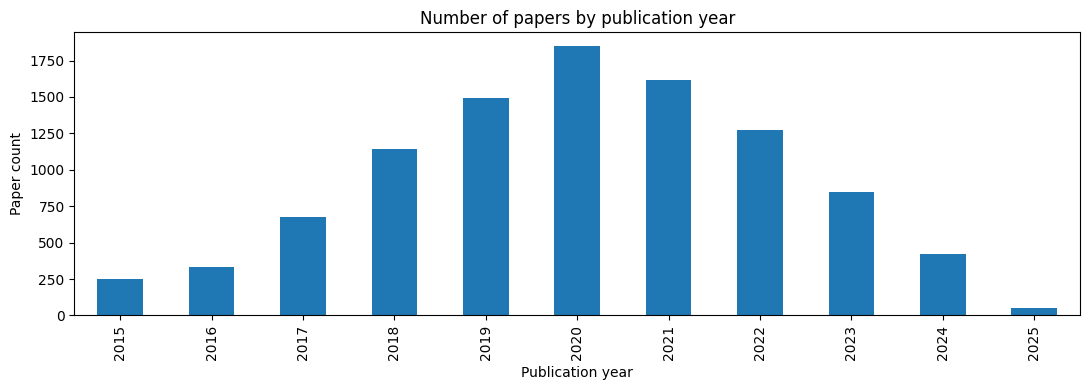

In [ ]:
year_counts = df.groupby("publication_year").size()
ax = year_counts.plot(kind="bar", figsize=(11, 4), title="Number of papers by publication year")
ax.set_xlabel("Publication year")
ax.set_ylabel("Paper count")
plt.tight_layout()
plt.show()

## 6. Citation Concentration and Distributional Inequality

Citation counts are typically highly skewed. Mean citation values may therefore conceal the extent to which a relatively small group of publications accounts for a large share of total citations.

This section evaluates concentration using:

- the Lorenz curve;
- the Gini coefficient;
- the citation share of the top 1 per cent, 5 per cent, and 10 per cent of publications; and
- the citation share of the bottom 50 per cent of publications.

### Interpretation of the Gini Coefficient

A value closer to zero indicates a more equal distribution of citations, while a value closer to one indicates greater concentration.

> **Important Distinction**  
> Citation inequality describes the distribution of recorded citations. It does not establish the quality, originality, social value, or methodological rigour of individual publications.


Gini coefficient of citation counts: 0.586


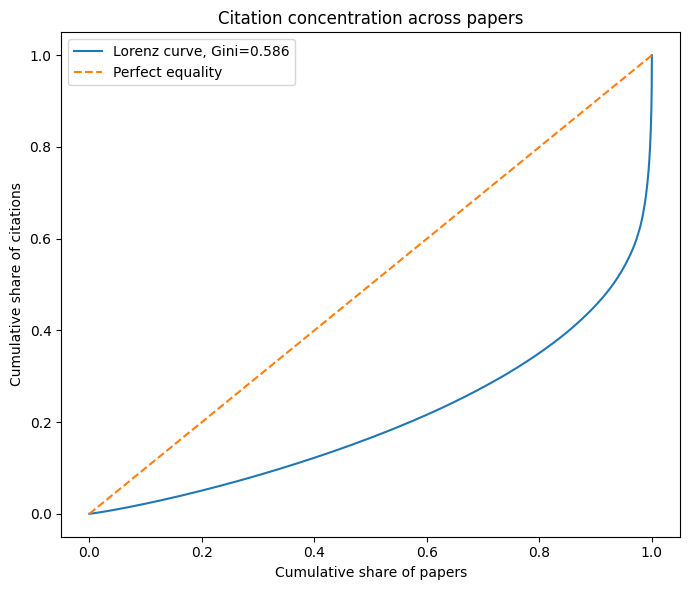

In [ ]:
def gini_coefficient(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    x = np.clip(x, 0, None)
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) / (n * x.sum())) - (n + 1) / n

citations_sorted = np.sort(df["citation_count"].fillna(0).to_numpy())
cumulative_citations = np.insert(np.cumsum(citations_sorted), 0, 0)
cumulative_citations = cumulative_citations / cumulative_citations[-1]
population_share = np.linspace(0, 1, len(cumulative_citations))

gini = gini_coefficient(citations_sorted)
print(f"Gini coefficient of citation counts: {gini:.3f}")

plt.figure(figsize=(7, 6))
plt.plot(population_share, cumulative_citations, label=f"Lorenz curve, Gini={gini:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")
plt.xlabel("Cumulative share of papers")
plt.ylabel("Cumulative share of citations")
plt.title("Citation concentration across papers")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def top_share(data, top_fraction):
    n = max(1, int(np.ceil(len(data) * top_fraction)))
    return data.nlargest(n).sum() / data.sum() * 100

concentration = pd.DataFrame({
    "paper_group": ["Top 1%", "Top 5%", "Top 10%", "Bottom 50%"],
    "share_of_all_citations_pct": [
        top_share(df["citation_count"], 0.01),
        top_share(df["citation_count"], 0.05),
        top_share(df["citation_count"], 0.10),
        df["citation_count"].nsmallest(len(df)//2).sum() / df["citation_count"].sum() * 100,
    ]
}).round(2)
concentration

,paper_group,share_of_all_citations_pct
0,Top 1%,30.15
1,Top 5%,46.29
2,Top 10%,54.56
3,Bottom 50%,16.58


## 7. Open-Access Status and Adjusted Citation Performance

Raw citation totals tend to favour older publications. Citation practices also differ substantially across academic fields. This section therefore compares open-access categories using both unadjusted annual citation rates and a field-year-adjusted measure.

For each publication, the relative impact index is calculated by dividing its annual citation rate by the median annual citation rate of publications in the same field and publication year.

### Relative Impact Index

| Value | Interpretation |
|---|---|
| Below 1 | Performance below the field-year median |
| Equal to 1 | Performance at the field-year median |
| Above 1 | Performance above the field-year median |

> **Methodological Limitation**  
> Differences across access categories are associative. They may reflect selection effects, journal characteristics, funding requirements, disciplinary norms, article quality, or other unobserved factors.


In [ ]:
raw_oa_summary = df.groupby("open_access_status").agg(
    papers=("paper_id", "size"),
    median_citations=("citation_count", "median"),
    median_annual_rate=("annual_citation_rate", "median"),
    mean_annual_rate=("annual_citation_rate", "mean")
).sort_values("median_annual_rate", ascending=False).round(2)
raw_oa_summary

,papers,median_citations,median_annual_rate,mean_annual_rate
open_access_status,,,,
hybrid,1368,114.5,20.73,38.48
gold,3809,114.0,19.60,32.41
bronze,492,117.5,16.83,30.73
green,1233,115.0,15.83,68.49
diamond,678,97.5,15.56,23.79
closed,2386,106.0,14.78,26.19


In [ ]:
benchmark = df.groupby(["field_of_study", "publication_year"])["annual_citation_rate"].transform("median")
global_median = df["annual_citation_rate"].median()
df["field_year_benchmark"] = benchmark.replace(0, np.nan).fillna(global_median)
df["relative_impact_index"] = df["annual_citation_rate"] / df["field_year_benchmark"]
df["relative_impact_index"] = df["relative_impact_index"].replace([np.inf, -np.inf], np.nan).clip(upper=50)

adjusted_oa = df.groupby("open_access_status").agg(
    papers=("paper_id", "size"),
    median_relative_impact=("relative_impact_index", "median"),
    mean_relative_impact=("relative_impact_index", "mean")
).query("papers >= 20").sort_values("median_relative_impact", ascending=False).round(3)
adjusted_oa

,papers,median_relative_impact,mean_relative_impact
open_access_status,,,
bronze,492,1.0,1.416
closed,2386,1.0,1.333
diamond,678,1.0,1.236
gold,3809,1.0,1.392
green,1233,1.0,1.700
hybrid,1368,1.0,1.421


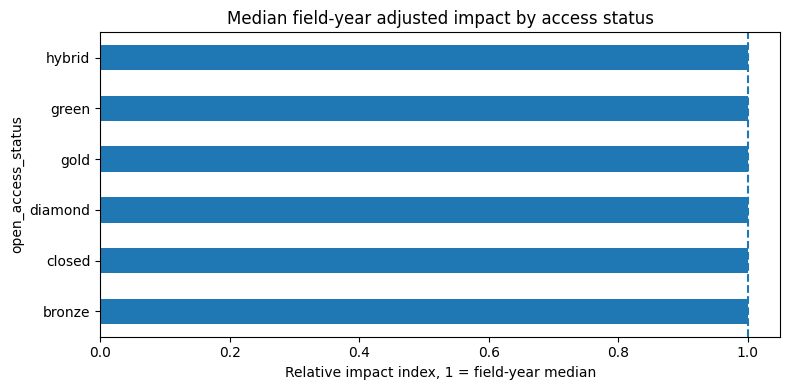

In [ ]:
ax = adjusted_oa["median_relative_impact"].sort_values().plot(
    kind="barh", figsize=(8, 4), title="Median field-year adjusted impact by access status"
)
ax.axvline(1, linestyle="--")
ax.set_xlabel("Relative impact index, 1 = field-year median")
plt.tight_layout()
plt.show()

## 8. International Collaboration and Citation Performance

This section compares domestically produced or single-country publications with internationally collaborative publications. The comparison includes citation totals, annual citation rates, adjusted impact, and institutional participation.

A year-specific comparison is also presented to reduce distortion arising from differences in publication age.

> **Interpretation Note**  
> International collaboration may be associated with greater visibility, broader networks, or access to complementary expertise. However, observational comparisons do not establish that collaboration itself causes higher citation performance.


In [ ]:
collab_summary = df.groupby("international_collaboration").agg(
    papers=("paper_id", "size"),
    median_citations=("citation_count", "median"),
    median_annual_rate=("annual_citation_rate", "median"),
    median_relative_impact=("relative_impact_index", "median"),
    median_institutions=("number_of_institutions", "median")
).rename(index={0: "Domestic / single-country", 1: "International collaboration"}).round(2)
collab_summary

,papers,median_citations,median_annual_rate,median_relative_impact,median_institutions
international_collaboration,,,,,
Domestic / single-country,6267,107.0,16.5,1.0,1.0
International collaboration,3699,119.0,19.6,1.0,4.0


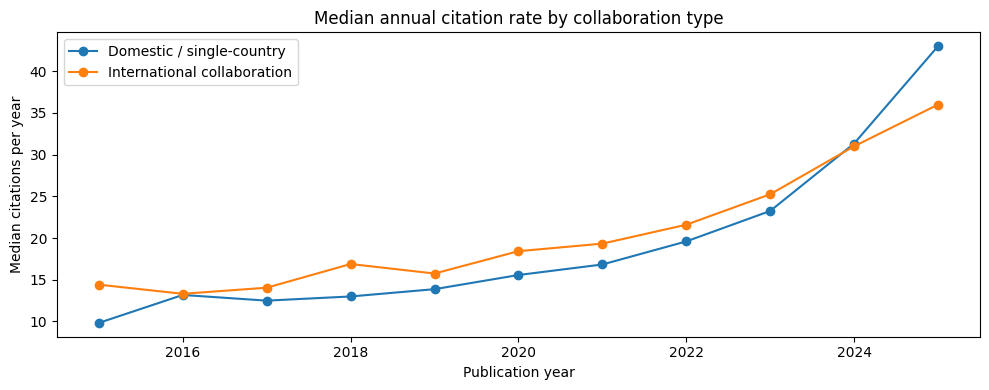

In [ ]:
# Compare collaboration within publication years to reduce age distortion
collab_by_year = df.groupby(["publication_year", "international_collaboration"])["annual_citation_rate"].median().unstack()
collab_by_year.columns = ["Domestic / single-country", "International collaboration"]
collab_by_year.plot(marker="o", figsize=(10, 4), title="Median annual citation rate by collaboration type")
plt.ylabel("Median citations per year")
plt.xlabel("Publication year")
plt.tight_layout()
plt.show()

## 9. Author-Team Size and Research Impact

The analysis examines whether citation performance varies across author-team categories. Median values are reported because citation-based indicators are generally right-skewed and may be strongly influenced by a small number of highly cited publications.

The comparison considers:

- annual citation performance;
- field-year-adjusted impact; and
- the proportion of internationally collaborative publications.

> **Analytical Caution**  
> Team size may proxy for research complexity, field norms, project scale, funding structure, or institutional reach. It should not be interpreted as an isolated determinant of impact.


In [ ]:
team_summary = df.groupby("team_size_group", observed=False).agg(
    papers=("paper_id", "size"),
    median_annual_rate=("annual_citation_rate", "median"),
    median_relative_impact=("relative_impact_index", "median"),
    international_share=("international_collaboration", "mean")
).reset_index()
team_summary["international_share_pct"] = (team_summary.pop("international_share") * 100).round(1)
team_summary.round(2)

,team_size_group,papers,median_annual_rate,median_relative_impact,international_share_pct
0,Solo,498,14.80,1.0,4.8
1,2-3,3078,16.44,1.0,20.1
2,4-6,4073,17.67,1.0,41.7
3,7-10,1624,19.27,1.0,57.3
4,11+,693,21.40,1.0,61.3


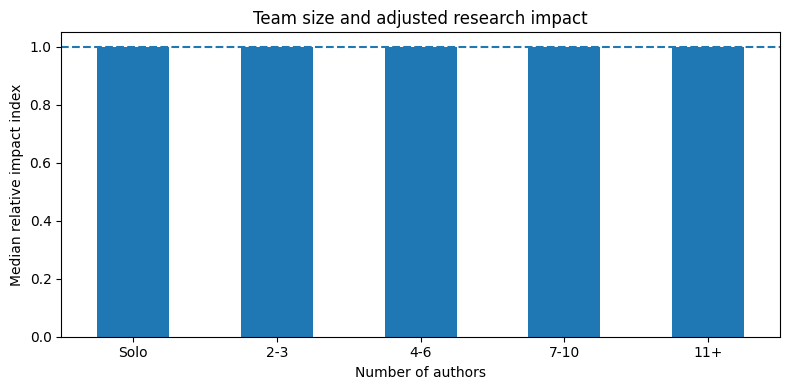

In [ ]:
ax = team_summary.plot(
    x="team_size_group", y="median_relative_impact", kind="bar",
    figsize=(8, 4), legend=False, title="Team size and adjusted research impact"
)
ax.axhline(1, linestyle="--")
ax.set_xlabel("Number of authors")
ax.set_ylabel("Median relative impact index")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Country-Level and Journal-Level Visibility

Country and journal summaries are produced to examine patterns of representation and adjusted research impact. Minimum publication thresholds are applied to reduce instability arising from very small groups.

The country-level analysis considers publication volume, annual citation rate, adjusted impact, open-access share, and international collaboration share. The journal-level analysis considers publication volume, total citations, annual citation rate, and adjusted impact.

> **Reporting Standard**  
> Rankings based on small numbers of observations should be avoided. Minimum group-size thresholds improve stability but do not eliminate sampling bias or differences in database coverage.


In [ ]:
MIN_GROUP_SIZE = 30
country_summary = df.groupby("institution_country").agg(
    papers=("paper_id", "size"),
    median_annual_rate=("annual_citation_rate", "median"),
    median_relative_impact=("relative_impact_index", "median"),
    open_access_share=("open_access", "mean"),
    international_share=("international_collaboration", "mean")
).query("papers >= @MIN_GROUP_SIZE")
country_summary["open_access_share_pct"] = country_summary.pop("open_access_share") * 100
country_summary["international_share_pct"] = country_summary.pop("international_share") * 100
country_summary.sort_values("median_relative_impact", ascending=False).head(15).round(2)

,papers,median_annual_rate,median_relative_impact,open_access_share_pct,international_share_pct
institution_country,,,,,
NO,39,19.00,1.04,89.74,28.21
AT,157,20.40,1.00,92.36,80.25
AU,480,19.55,1.00,83.96,72.29
BD,146,23.17,1.00,73.97,49.32
AE,131,19.80,1.00,84.73,82.44
BR,120,16.73,1.00,74.17,60.00
CA,466,18.93,1.00,70.39,54.72
CH,234,18.73,1.00,86.75,67.52
CN,1271,19.29,1.00,68.84,51.38


In [ ]:
journal_summary = df.groupby("journal").agg(
    papers=("paper_id", "size"),
    total_citations=("citation_count", "sum"),
    median_annual_rate=("annual_citation_rate", "median"),
    median_relative_impact=("relative_impact_index", "median")
).query("papers >= 15")

print("Most represented journals")
display(journal_summary.sort_values("papers", ascending=False).head(12).round(2))
print("Strongest median adjusted impact among journals with at least 15 papers")
display(journal_summary.sort_values("median_relative_impact", ascending=False).head(12).round(2))

Most represented journals


,papers,total_citations,median_annual_rate,median_relative_impact
journal,,,,
Unknown,926,299906,12.00,1.0
IEEE Access,362,73626,20.11,1.0
arXiv (Cornell University),240,147343,13.55,1.0
Scientific Reports,225,32676,17.43,1.0
Sensors,160,25593,18.58,1.0
Nature Communications,155,29099,27.14,1.0
PLoS ONE,131,31415,14.67,1.0
Remote Sensing,129,21027,18.12,1.0
Applied Sciences,109,14177,18.00,1.0


Strongest median adjusted impact among journals with at least 15 papers


,papers,total_citations,median_annual_rate,median_relative_impact
journal,,,,
IEEE Communications Surveys & Tutorials,43,18734,34.75,1.81
Journal Of Big Data,40,37334,34.17,1.52
ACM Computing Surveys,46,13043,28.75,1.51
Geoscience Frontiers,16,4515,32.27,1.29
IEEE Sensors Journal,18,2425,19.19,1.21
IEEE Internet of Things Journal,35,5828,21.75,1.20
Bioinformatics,23,6310,21.00,1.04
npj Digital Medicine,37,10410,29.80,1.02
Energy Reports,16,2173,28.33,1.01


## 11. Descriptive Publication Archetypes Through Clustering

Clustering is used to identify groups of publications with similar structural and bibliometric characteristics. The analysis includes authorship, institutional breadth, reference count, text length, open-access status, international collaboration, and annual citation performance.

The number of clusters is selected by comparing silhouette scores across a defined range of candidate solutions.

> **Purpose of the Analysis**  
> The clusters are descriptive archetypes rather than quality categories. Cluster labels are arbitrary, and a higher numerical cluster identifier does not indicate superior performance.


In [ ]:
cluster_features = [
    "number_of_authors", "number_of_institutions", "references_count",
    "title_length_words", "abstract_length_words", "keyword_count",
    "open_access", "international_collaboration", "log_annual_citation_rate"
]
cluster_data = df[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
scaled = StandardScaler().fit_transform(cluster_data)

silhouette_results = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(scaled)
    silhouette_results.append((k, silhouette_score(scaled, labels, sample_size=min(5000, len(df)), random_state=RANDOM_STATE)))

silhouette_table = pd.DataFrame(silhouette_results, columns=["clusters", "silhouette_score"])
best_k = int(silhouette_table.loc[silhouette_table["silhouette_score"].idxmax(), "clusters"])
print("Selected clusters:", best_k)
display(silhouette_table.round(3))

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=30)
df["paper_archetype"] = kmeans.fit_predict(scaled)

Selected clusters: 6


,clusters,silhouette_score
0,2,0.207
1,3,0.211
2,4,0.225
3,5,0.236
4,6,0.238


In [ ]:
archetype_profile = df.groupby("paper_archetype").agg(
    papers=("paper_id", "size"),
    median_authors=("number_of_authors", "median"),
    median_institutions=("number_of_institutions", "median"),
    median_references=("references_count", "median"),
    median_abstract_words=("abstract_length_words", "median"),
    open_access_share=("open_access", "mean"),
    international_share=("international_collaboration", "mean"),
    median_annual_rate=("annual_citation_rate", "median"),
    median_relative_impact=("relative_impact_index", "median")
)
archetype_profile["open_access_share_pct"] = archetype_profile.pop("open_access_share") * 100
archetype_profile["international_share_pct"] = archetype_profile.pop("international_share") * 100
archetype_profile.round(2)

,papers,median_authors,median_institutions,median_references,median_abstract_words,median_annual_rate,median_relative_impact,open_access_share_pct,international_share_pct
paper_archetype,,,,,,,,,
0,2658,6.0,4.0,56.0,207.0,19.14,1.00,97.59,98.91
1,2058,4.0,2.0,35.0,174.5,13.75,1.00,0.00,24.98
2,3765,4.0,1.0,49.0,198.0,16.71,1.00,100.00,0.00
3,772,4.0,2.0,204.0,178.0,51.46,1.28,84.59,44.82
4,638,4.0,2.0,42.0,164.5,17.25,1.00,77.74,23.67
5,75,42.0,21.0,67.0,205.0,29.00,1.00,96.00,78.67


## 12. Identification of Unusual Publications

Isolation Forest is applied to identify records with unusual combinations of bibliometric characteristics. Such records may represent:

- genuinely exceptional publications;
- highly cited or unusually collaborative work;
- atypical reference or authorship patterns;
- data-entry inconsistencies; or
- metadata errors.

> **Review Requirement**  
> An anomaly flag is not a judgement of research quality. Every unusual record should be reviewed in context before any conclusion is drawn.


In [ ]:
anomaly_features = [
    "citation_count_log", "references_count_log", "number_of_authors_log",
    "abstract_length_words", "keyword_count", "citation_rate_per_year"
]
anomaly_data = df[anomaly_features].replace([np.inf, -np.inf], np.nan).fillna(0)
iso = IsolationForest(contamination=0.015, random_state=RANDOM_STATE)
df["anomaly_flag"] = iso.fit_predict(anomaly_data)
df["anomaly_score"] = -iso.score_samples(anomaly_data)

unusual_papers = df.nlargest(20, "anomaly_score")[[
    "paper_title", "publication_year", "journal", "number_of_authors",
    "references_count", "citation_count", "annual_citation_rate", "anomaly_score"
]]
unusual_papers

,paper_title,publication_year,journal,number_of_authors,references_count,citation_count,annual_citation_rate,anomaly_score
4291,MizAR 60 for Mizar 50,2023,DROPS (Schloss Dagstuhl – Leibniz Center for Informatics),9,0,76297,19074.250000,0.749224
272,"PyTorch: An Imperative Style, High-Performance Deep Learning Library",2019,arXiv (Cornell University),21,0,16187,2023.375000,0.745153
4876,An introduction to statistical learning with applications in R,2021,Statistical Theory and Related Fields,3,0,1660,276.666667,0.742257
2249,Distilling the Knowledge in a Neural Network,2015,arXiv (Cornell University),3,9,13962,1163.500000,0.741475
24,Introduction to Machine Learning,2019,Series in machine perception and artificial intelligence,0,0,1659,207.375000,0.740990
1103,Learning Multiple Layers of Features from Tiny Images,2024,Unknown,1,3,25499,8499.666667,0.730793
9851,Deep Learning,2016,MIT Press eBooks,3,0,8960,814.545455,0.730235
384,Highly accurate protein structure prediction with AlphaFold,2021,Nature,34,89,45078,7513.000000,0.726249
5102,Diagnosing Non-Intermittent Anomalies in Reinforcement Learning Policy Executions (Sho...,2017,arXiv (Cornell University),3,11,11321,1132.100000,0.722752
7588,On Assessing ML Model Robustness: A Methodological Framework (Academic Track),2025,Dagstuhl Research Online Publication Server,2,0,4606,2303.000000,0.718989


## 13. Keyword Frequency and Co-Occurrence Analysis

The dataset contains semicolon-separated keyword strings. These are normalised and used to calculate individual keyword frequency and pairwise co-occurrence.

The resulting tables may support:

- thematic mapping;
- literature review planning;
- network visualisation;
- identification of recurring conceptual combinations; and
- preliminary topic curation.

> **Scope Limitation**  
> Keyword co-occurrence reflects the vocabulary supplied in the dataset. It does not capture synonymy, semantic similarity, conceptual hierarchy, or the full meaning of titles and abstracts.


In [ ]:
keyword_frequency = Counter()
pair_frequency = Counter()

for terms in df["keyword_list"]:
    keyword_frequency.update(terms)
    for pair in combinations(sorted(set(terms)), 2):
        pair_frequency[pair] += 1

top_keywords = pd.DataFrame(keyword_frequency.most_common(25), columns=["keyword", "paper_count"])
top_pairs = pd.DataFrame(
    [(a, b, count) for (a, b), count in pair_frequency.most_common(30)],
    columns=["keyword_1", "keyword_2", "co_occurrence_count"]
)

display(top_keywords.head(20))
display(top_pairs.head(20))

,keyword,paper_count
0,computer science,7137
1,artificial intelligence,4900
2,machine learning,4138
3,...,983
4,support vector machine,972
5,medicine,893
6,random forest,878
7,data science,505
8,artificial neural network,495
9,materials science,380


,keyword_1,keyword_2,co_occurrence_count
0,artificial intelligence,computer science,4180
1,computer science,machine learning,3434
2,artificial intelligence,machine learning,3284
3,...,computer science,679
4,computer science,support vector machine,634
5,artificial intelligence,support vector machine,621
6,machine learning,support vector machine,530
7,machine learning,random forest,526
8,...,artificial intelligence,512
9,computer science,random forest,489


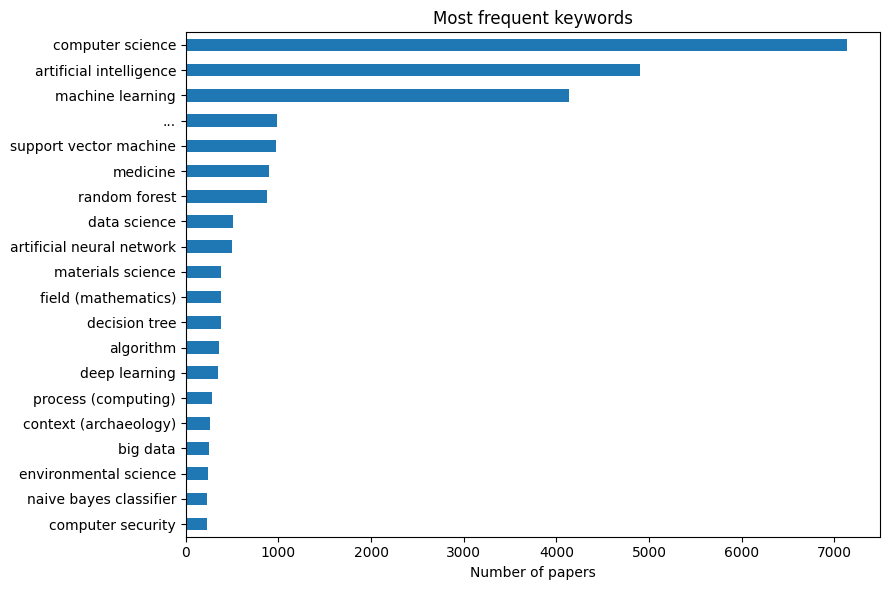

In [ ]:
ax = top_keywords.sort_values("paper_count").tail(20).plot(
    x="keyword", y="paper_count", kind="barh", figsize=(9, 6), legend=False,
    title="Most frequent keywords"
)
ax.set_xlabel("Number of papers")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 14. Classification Benchmark for High Adjusted Impact

This section develops an optional classification benchmark for identifying publications in the top 20 per cent of field-year-adjusted impact.

The model excludes direct citation outcomes and unstructured text variables to reduce obvious information leakage. The predictors consist of publication-year, authorship, institutional, reference, text-length, access, and collaboration variables.

### Evaluation Criteria

The model is assessed using:

- receiver operating characteristic area under the curve;
- precision;
- recall;
- F1-score; and
- feature importance.

> **Model-Use Limitation**  
> The classifier is a predictive benchmark, not a causal model or a publication-quality assessment tool. Its performance may decline when applied to other fields, databases, time periods, or sampling frames.


In [ ]:
threshold = df["relative_impact_index"].quantile(0.80)
df["high_adjusted_impact"] = (df["relative_impact_index"] >= threshold).astype(int)

model_features = [
    "number_of_authors", "number_of_institutions", "references_count",
    "title_length_words", "abstract_length_words", "keyword_count",
    "open_access", "international_collaboration", "publication_year"
]
X = df[model_features].fillna(0)
y = df["high_adjusted_impact"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

clf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
prob = clf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, prob), 3))
print(classification_report(y_test, pred, digits=3))

feature_importance = pd.Series(clf.feature_importances_, index=model_features).sort_values(ascending=False)
feature_importance.to_frame("importance")

ROC-AUC: 0.597
              precision    recall  f1-score   support

           0      0.821     0.921     0.868      1993
           1      0.387     0.198     0.262       499

    accuracy                          0.776      2492
   macro avg      0.604     0.560     0.565      2492
weighted avg      0.734     0.776     0.747      2492



,importance
references_count,0.252335
abstract_length_words,0.236590
title_length_words,0.134603
number_of_authors,0.113588
publication_year,0.108640
number_of_institutions,0.085263
keyword_count,0.030391
international_collaboration,0.022381
open_access,0.016210


## 15. Export of Reusable Analytical Outputs

The notebook exports cleaned data and summary tables for further analysis, validation, and reporting.

The generated files include:

| Output | Purpose |
|---|---|
| `citation_metadata_enriched.csv` | Cleaned publication-level dataset with derived variables |
| `data_quality_audit.csv` | Variable-level missingness and uniqueness audit |
| `country_impact_summary.csv` | Country-level bibliometric summary |
| `journal_impact_summary.csv` | Journal-level bibliometric summary |
| `paper_archetype_profiles.csv` | Cluster profile table |
| `unusual_papers_for_review.csv` | Records identified for contextual review |
| `keyword_frequency.csv` | Keyword frequency table |
| `keyword_cooccurrence.csv` | Pairwise keyword co-occurrence table |

> **Documentation Recommendation**  
> Exported files should be accompanied by a data dictionary, source description, extraction date, and clear definitions of all derived indicators.


In [ ]:
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("/content") if Path("/content").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

export_columns = [c for c in df.columns if c != "keyword_list"]
df[export_columns].to_csv(OUTPUT_DIR / "citation_metadata_enriched.csv", index=False)
audit_table.to_csv(OUTPUT_DIR / "data_quality_audit.csv")
country_summary.to_csv(OUTPUT_DIR / "country_impact_summary.csv")
journal_summary.to_csv(OUTPUT_DIR / "journal_impact_summary.csv")
archetype_profile.to_csv(OUTPUT_DIR / "paper_archetype_profiles.csv")
unusual_papers.to_csv(OUTPUT_DIR / "unusual_papers_for_review.csv", index=False)
top_keywords.to_csv(OUTPUT_DIR / "keyword_frequency.csv", index=False)
top_pairs.to_csv(OUTPUT_DIR / "keyword_cooccurrence.csv", index=False)

print("Files created:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    if path.name in {
        "citation_metadata_enriched.csv", "data_quality_audit.csv", "country_impact_summary.csv",
        "journal_impact_summary.csv", "paper_archetype_profiles.csv", "unusual_papers_for_review.csv",
        "keyword_frequency.csv", "keyword_cooccurrence.csv"
    }:
        print("-", path)

Files created:
- /content/citation_metadata_enriched.csv
- /content/country_impact_summary.csv
- /content/data_quality_audit.csv
- /content/journal_impact_summary.csv
- /content/keyword_cooccurrence.csv
- /content/keyword_frequency.csv
- /content/paper_archetype_profiles.csv
- /content/unusual_papers_for_review.csv


## 16. Interpretation Framework, Limitations, and Concluding Remarks

### Interpretation Principles

1. **Citation concentration is not equivalent to research quality.**  
   It describes how recorded citations are distributed across publications.

2. **Observed differences are not necessarily causal.**  
   Open-access, collaboration, team-size, country, and journal comparisons may be influenced by selection effects and unmeasured characteristics.

3. **Adjusted impact remains an approximation.**  
   The relative impact index improves comparability across fields and years, but its accuracy depends on the quality and granularity of field classifications.

4. **Clusters are descriptive rather than evaluative.**  
   Publication archetypes summarise recurring patterns and do not constitute a formal ranking.

5. **Anomaly detection requires substantive review.**  
   Unusual observations may represent either valuable exceptions or problematic metadata.

6. **Keyword co-occurrence is a limited thematic indicator.**  
   It should not be treated as a substitute for full-text topic modelling or expert interpretation.

7. **Predictive performance does not imply explanatory validity.**  
   A classification model may distinguish high-impact records without identifying the true mechanisms responsible for impact.

---


### Proposed Value Statement

This notebook transforms publication metadata into a structured set of bibliometric indicators covering citation concentration, field- and year-adjusted impact, open-access status, international collaboration, team structure, country and journal visibility, publication archetypes, anomalous records, keyword relationships, and predictive benchmarking.

### Concluding Statement

The analysis provides a reproducible framework for examining scholarly visibility at multiple levels. Its principal value lies in combining descriptive bibliometrics, distributional analysis, unsupervised learning, anomaly detection, and predictive modelling within a single workflow. The resulting evidence should be interpreted cautiously and, where appropriate, supplemented by disciplinary expertise, richer metadata, and stronger research designs.
